Data is comming from the archive http://www.laurent-duval.eu/opus-dual-spls-sparse-pls/Data-dual-sPLS-NIR-near-infrared-spectra-density/matrixXYNir-CSV-dual-sparse-pls.7z (see **Dataset of near-infrared (NIR) spectral data for prediction of organic matter and total carbon in agricultural soil using homemade NIR spectrometer**). Like the paper said, X matrix is tranformed using the Savitzky–Golay filter before use. Here we introduce Dual-sPLS performance using *RMSE* metric for different norms on real data (NIR dataset). Norms $\Omega$ includes :

* Lasso (*lasso.py*)
* Ridge (*ridge.py*)
* GLA (*GLA.py*)
* GLB (*GLB.py*)
* GLC (*GLC.py*)
* $\mathcal{l}_2$ norm (*LS.py*)

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns 
from sklearn.model_selection import train_test_split

# Dual-sPLS library - norms
from dual_spls.lasso import dual_spls_lasso
from dual_spls.ridge import d_spls_ridge
from dual_spls.GLA   import dual_spls_gla_random
from dual_spls.GLB   import dual_spls_glb
from dual_spls.GLC   import dual_spls_glc
from dual_spls.LS    import d_spls_ls

sns.set_style("darkgrid")

In [2]:
# Import dataset
X = pd.read_csv(
    "../data/matrixXNirSpectrumDerivative.csv"
)
X.head()

,0.00293123424053193,0.00255436311875071,0.0020018325320312,0.00196149115051542,0.00192856660911015,0.0026838980615139,0.00185868952955519,0.00212735352771622,0.00210245932851519,0.00222007227795464,...,0.00218016813908305,0.00187072977423667,0.00272921706948961,0.00301864594221115,0.00199910349079539,0.00191627740859985,0.00268596070153373,0.00232852495142393,0.00253164342471531,0.00188808962702751
0,0.002981,0.002625,0.002059,0.002022,0.001990,0.002611,0.001919,0.002184,0.002161,0.002267,...,0.002229,0.001931,0.002490,0.002956,0.002058,0.001977,0.002400,0.002340,0.002562,0.001951
1,0.003050,0.002717,0.002144,0.002109,0.002077,0.002578,0.002006,0.002266,0.002243,0.002340,...,0.002302,0.002017,0.002316,0.002925,0.002146,0.002065,0.002189,0.002380,0.002616,0.002038
2,0.003139,0.002831,0.002253,0.002213,0.002184,0.002584,0.002115,0.002367,0.002342,0.002433,...,0.002399,0.002127,0.002213,0.002929,0.002257,0.002174,0.002058,0.002448,0.002693,0.002147
3,0.003246,0.002962,0.002377,0.002333,0.002307,0.002632,0.002241,0.002483,0.002455,0.002542,...,0.002510,0.002253,0.002180,0.002969,0.002383,0.002299,0.002007,0.002540,0.002795,0.002272
4,0.003365,0.003105,0.002510,0.002468,0.002444,0.002715,0.002380,0.002614,0.002584,0.002666,...,0.002634,0.002391,0.002209,0.003042,0.002518,0.002436,0.002026,0.002651,0.002918,0.002409


In [3]:
y = pd.read_csv("../data/matrixYNirPropertyDensityNormalized.csv", header=None)
y.head()

,0,1,2,3,4,5,6,7,8,9,...,198,199,200,201,202,203,204,205,206,207
0,0.536704,0.616918,0.848809,0.894507,0.899854,0.268838,0.906174,0.794361,0.854157,0.755955,...,0.782207,0.90666,0.129315,0.337385,0.870685,0.90034,0.085561,0.506077,0.609626,0.913952


In [4]:
from sklearn.cluster import AgglomerativeClustering

# ----------- Data (adapted to the lib) ----------- #
X = pd.read_csv(
    "../data/matrixXNirSpectrumDerivative.csv",
     header=None
).T.values
y = pd.read_csv(
    "../data/matrixYNirPropertyDensityNormalized.csv",
    header=None
).values.ravel()

# ----------- Params ----------- #

n_comp = 6
labels = AgglomerativeClustering(n_clusters=25).fit(X.T).labels_ # for GL*

# GLA
indG = labels + 1

nG = indG.max()
ppnu = np.repeat(0.5, nG)

# GLB
nG = indG.max()
gamma = np.repeat(1.0 / nG, nG)

# ----------- Train ----------- #

lasso = dual_spls_lasso(X, y, n_components=n_comp, ppnu=0.8)
ridge = d_spls_ridge(X, y, n_components=n_comp, ppnu=0.75, nu2=0.1)
gla = dual_spls_gla_random(X, y, n_components=n_comp, ppnu=ppnu, indG=indG)
glb = dual_spls_glb(X, y, n_components=n_comp, ppnu=ppnu, indG=indG)
glc = dual_spls_glc(X, y, n_components=n_comp, ppnu=ppnu, indG=indG, gamma=gamma)
ls = d_spls_ls(X, y, n_components=n_comp, ppnu=0.8, verbose=True)

Dual PLS Lasso ic=1 lambda1=0.0133 mu=1.1291 nu=0.014997266498593438 nbzeros=2075
Dual PLS Lasso ic=2 lambda1=0.0928 mu=0.0563 nu=0.00522297464128926 nbzeros=1893
Dual PLS Lasso ic=3 lambda1=0.0108 mu=0.0172 nu=0.0001862201941345145 nbzeros=1668
Dual PLS Lasso ic=4 lambda1=0.0564 mu=0.0049 nu=0.0002775811621496032 nbzeros=1538
Dual PLS Lasso ic=5 lambda1=0.0741 mu=0.0041 nu=0.0003012961077906575 nbzeros=1518
Dual PLS Lasso ic=6 lambda1=0.0396 mu=0.0013 nu=5.2141639262318896e-05 nbzeros=1474
Dual PLS Ridge ic=1 lambda1=0.0122 mu=1.1198 nu2=0.1 nbzeros=1945
Dual PLS Ridge ic=2 lambda1=0.0710 mu=0.0651 nu2=0.1 nbzeros=1763
Dual PLS Ridge ic=3 lambda1=0.0163 mu=0.0156 nu2=0.1 nbzeros=1566
Dual PLS Ridge ic=4 lambda1=0.0417 mu=0.0059 nu2=0.1 nbzeros=1457
Dual PLS Ridge ic=5 lambda1=0.0462 mu=0.0055 nu2=0.1 nbzeros=1399
Dual PLS Ridge ic=6 lambda1=0.0327 mu=0.0015 nu2=0.1 nbzeros=1226
Dual PLS GLA ic=1, nbzeros=2594
Dual PLS GLA ic=2, nbzeros=2594
Dual PLS GLA ic=3, nbzeros=2594
Dual PLS GLA

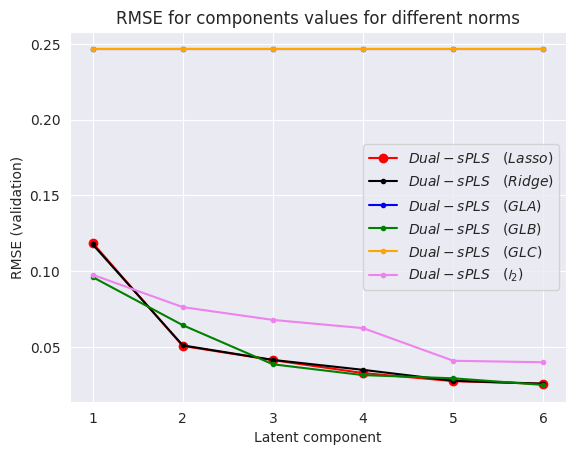

In [5]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Lasso
rmse_lasso = []
for k in range(lasso["fitted_values"].shape[1]):
    y_hat = lasso["fitted_values"][:, k]
    rmse_lasso.append(np.sqrt(mean_squared_error(y, y_hat)))

# Ridge
rmse_ridge = []
for k in range(ridge["fitted_values"].shape[1]):
    y_hat = ridge["fitted_values"][:, k]
    rmse_ridge.append(np.sqrt(mean_squared_error(y, y_hat)))

# GLA
rmse_gla = []
for k in range(gla["fitted_values"].shape[1]):
    y_hat = gla["fitted_values"][:, k]
    rmse_gla.append(np.sqrt(mean_squared_error(y, y_hat)))

# GLB
rmse_glb = []
for k in range(glb["fitted_values"].shape[1]):
    y_hat = glb["fitted_values"][:, k]
    rmse_glb.append(np.sqrt(mean_squared_error(y, y_hat)))

# GLC
rmse_glc = []
for k in range(glc["fitted_values"].shape[1]):
    y_hat = glc["fitted_values"][:, k]
    rmse_glc.append(np.sqrt(mean_squared_error(y, y_hat)))

# LS
rmse_ls = []
for k in range(ls["fitted_values"].shape[1]):
    y_hat = ls["fitted_values"][:, k]
    rmse_ls.append(np.sqrt(mean_squared_error(y, y_hat)))

plt.plot(range(1, len(rmse_lasso)+1), rmse_lasso, marker="o", color='red', label="$Dual-sPLS \\quad (Lasso)$")
plt.plot(range(1, len(rmse_ridge)+1), rmse_ridge, marker=".", color='black', label="$Dual-sPLS \\quad (Ridge)$")
plt.plot(range(1, len(rmse_gla)+1), rmse_gla, marker=".", color='blue', label="$Dual-sPLS \\quad (GLA)$")
plt.plot(range(1, len(rmse_glb)+1), rmse_glb, marker=".", color='green', label="$Dual-sPLS \\quad (GLB)$")
plt.plot(range(1, len(rmse_glc)+1), rmse_gla, marker=".", color='orange', label="$Dual-sPLS \\quad (GLC)$")
plt.plot(range(1, len(rmse_gla)+1), rmse_ls, marker=".", color='violet', label="$Dual-sPLS \\quad (\\mathcal{l}_2)$")


plt.xlabel("Latent component")
plt.ylabel("RMSE (validation)")
plt.title("RMSE for components values for different norms")
plt.legend()
plt.show()